<div>
<hr style="width: 80%;">

<p align="center" style="font-size: 20px; color: #1f4e79; margin: 0;"><strong>Maestría en Inteligencia Artificial — Segundo Semestre - Grupo 2</strong>
</p>

<p align="center" style="font-size: 16px; margin: 0;"><strong>Asignatura:</strong> <em>Visión por Computador</em>
</p>

<p align="center"><strong>Docente:</strong> Carlos Alejandro Espejo Villaraga

<p align="center" style="font-size: 20px; color: #1f4e79; margin: 0;"><strong>Actividad 5: Taller</strong> — “Evaluemos un modelo d elcasificación”</p>

<p align="center" style="font-size: 16px; font-style: italic; margin: 0;"><em>Future Professionals in Computer Vision</em></p>

<hr style="width: 80%;">

<p style="font-size: 16px; margin: 0;"><strong>Presentado por:</strong>
</p>
<p style="font-size: 16px; margin: 0;">
    🎓Diana Carolina González Díaz  <br>
    🎓Santiago Baquero Delgado
</p>  

***   
</div>

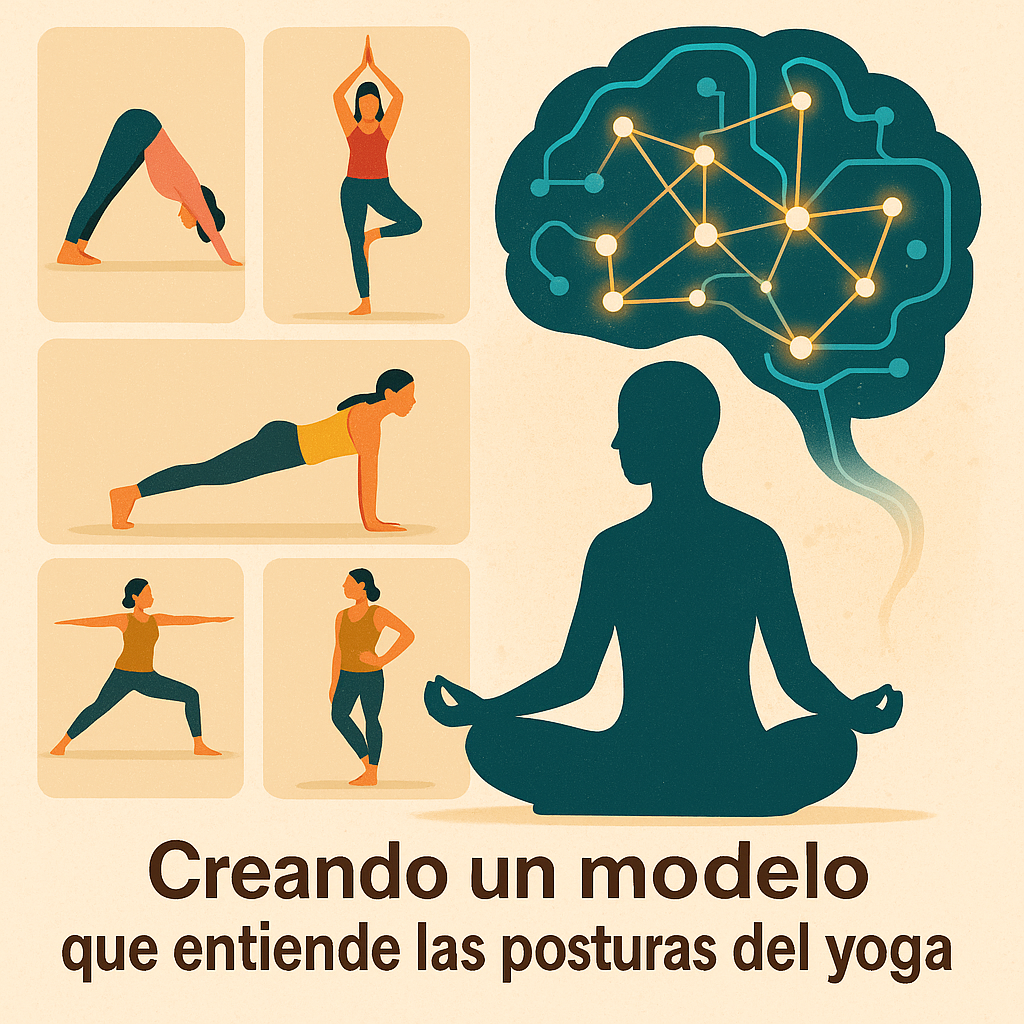

####**Librerías necesarias**






--------

En este paso cargamos las herramientas que usaremos para construir y entrenar el modelo (TensorFlow, Keras y Matplotlib).

In [ ]:
# Importar librerías y rutas base
import os
import cv2
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

###**Paso 1: Descargar el dataset desde KaggleHub**

------


En este paso importamos el conjunto de imágenes directamente desde Kaggle usando KaggleHub.
Así evitamos subir archivos manualmente y tenemos acceso rápido y ordenado a las carpetas del dataset de posturas de yoga.

In [ ]:
import kagglehub
import shutil
import os

# 1️⃣ Descargar el dataset desde Kaggle
print("⏳ Descargando dataset desde Kaggle...")
path = kagglehub.dataset_download("niharika41298/yoga-poses-dataset")
print("Descarga completada.")
print("📂 Ruta original del dataset:", path)

# 2️⃣ Crear carpeta visible en /content
destino = "/content/yoga_poses_dataset"

# Si ya existe, la borramos
if os.path.exists(destino):
    shutil.rmtree(destino)

# Copiamos todo el contenido descargado a /content
shutil.copytree(path, destino)

print("✅ Dataset copiado a:", destino)
print("Ahora puedes ver las carpetas directamente en el panel izquierdo de Colab.")

⏳ Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'yoga-poses-dataset' dataset.
Descarga completada.
📂 Ruta original del dataset: /kaggle/input/yoga-poses-dataset
✅ Dataset copiado a: /content/yoga_poses_dataset
Ahora puedes ver las carpetas directamente en el panel izquierdo de Colab.


###**Paso2:  Verificar la estructura del dataset**

-----



En este paso revisamos cómo está organizado el conjunto de imágenes descargado.
Listamos las carpetas principales y exploramos una de ellas para asegurarnos de que las fotos de cada postura (por ejemplo, tree, warrior2, downdog) estén bien clasificadas y listas para usar en el entrenamiento del modelo.

In [ ]:
# Usamos automáticamente la ruta original del dataset

# Listar las carpetas principales
for folder in os.listdir(path):
    print("📁", folder)

# Accedemos a la subcarpeta principal (por ejemplo, "Yoga-Dataset")
subfolder = os.path.join(path, os.listdir(path)[0])
print("\n🔍 Explorando dentro de:", subfolder)
print(os.listdir(subfolder)[:10])

📁 DATASET

🔍 Explorando dentro de: /kaggle/input/yoga-poses-dataset/DATASET
['TEST', 'TRAIN']


###**Paso 3. Definir rutas del dataset**

En este paso indicamos al programa dónde están guardadas las imágenes de entrenamiento y prueba dentro del conjunto descargado.
Luego, usamos os.listdir() para comprobar que las carpetas existen y contienen las clases de posturas de yoga (por ejemplo, tree, plank, warrior2).

In [ ]:
# Definir rutas de TRAIN y TEST de forma dinámica
train_path = os.path.join(subfolder, "TRAIN")
test_path = os.path.join(subfolder, "TEST")

print("\n📁 Carpetas dentro de TRAIN:")
print(os.listdir(train_path))

print("\n📁 Carpetas dentro de TEST:")
print(os.listdir(test_path))


📁 Carpetas dentro de TRAIN:
['downdog', 'tree', 'plank', 'warrior2', 'goddess']

📁 Carpetas dentro de TEST:
['downdog', 'tree', 'plank', 'warrior2', 'goddess']


####**Paso 4. Crear datasets base**


En este paso cargamos las imágenes y las organizamos para que el modelo pueda aprender de ellas.
El 80 % de las fotos se usa para entrenar al modelo y el 20 % restante para validar qué tan bien está aprendiendo.
Además, se redimensionan todas las imágenes al mismo tamaño (224 × 224 píxeles) y se agrupan en lotes de 32 para optimizar el proceso. Es importante resaltar que se debe asigna el camino exacto de la carpeta TRAIN que se creó.

In [ ]:
# Cargamos las imágenes de yoga para entrenar y validar el modelo

# Primero, indicamos en qué carpetas están las imágenes.
# Estas rutas se crearon en el bloque anterior.
train_dir = train_path   # Carpeta con las imágenes de entrenamiento
test_dir = test_path     # Carpeta con las imágenes de prueba

# 1. Creamos el conjunto de entrenamiento
# El modelo tomará el 80% de las imágenes para aprender.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,   # El 20% se deja para validación
    subset="training",      # Este bloque usa el 80% para entrenar
    seed=123,               # Fijamos un número aleatorio para poder repetir los resultados
    image_size=(224, 224),  # Tamaño de las imágenes
    batch_size=32           # Número de imágenes que procesa por grupo
)

# 2. Creamos el conjunto de validación
# Este conjunto sirve para comprobar si el modelo está aprendiendo bien o solo memorizando.
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,   # Usa el mismo 20% de antes
    subset="validation",    # Este bloque usa ese 20% para validar
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# 3. Revisamos las clases detectadas
# Aquí veremos los nombres de las carpetas, una por cada postura de yoga.
class_names = train_ds.class_names
print("Clases detectadas:", class_names)

Found 1081 files belonging to 5 classes.
Using 865 files for training.
Found 1081 files belonging to 5 classes.
Using 216 files for validation.
Clases detectadas: ['downdog', 'goddess', 'plank', 'tree', 'warrior2']


####**Paso 5. Optimizar rendimiento de lectura**

-----


En este paso mejoramos la velocidad con la que el modelo lee las imágenes durante el entrenamiento.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE).ignore_errors()
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE).ignore_errors()

####**Paso 6. Modelo base preentrenado (MobileNetV2)**


------



En este paso utilizamos un modelo ya entrenado llamado MobileNetV2, que ha aprendido a reconocer miles de objetos en el conjunto de datos ImageNet.
Aprovechamos ese conocimiento previo para que nuestro modelo no empiece desde cero, sino que parte de una base visual ya entrenada que entiende formas, colores y patrones comunes en las fotos.

In [ ]:
# 1. Cargar modelo base preentrenado
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Quitamos la última capa
    weights='imagenet'  # Pesos entrenados en ImageNet
)
base_model.trainable = False  # Congelamos los pesos base

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Importante:**

Lo que se hizo fue fue traer un modelo ya conocido llamado MobileNetV2,
pero solo su parte base, la que sabe reconocer formas, colores y texturas gracias a haber sido entrenado con millones de fotos (el conjunto ImageNet) pero todavía no sabe identificar las posturas de yoga, porque no ha aprendido las clases específicas (tree, plank, warrior2, etc.).

####**Paso 7. Crear el modelo y entrenar**


------



En este paso construimos la parte final de nuestro modelo, añadiendo nuevas capas que le permitirán aprender a reconocer las posturas de yoga específicas.
Primero, resumimos la información visual con GlobalAveragePooling2D, luego usamos Dropout para evitar que el modelo se sobreentrene y, finalmente, agregamos una capa de salida con tantas neuronas como clases tengamos.
Al compilarlo, definimos cómo va a aprender (optimizador adam), cómo medirá el error (loss) y qué indicador usará para evaluar su desempeño (accuracy).

In [ ]:
# Crear, entrenar y guardar el modelo


# 1️. Crear el modelo final (añadimos capas personalizadas)
model = models.Sequential([
    base_model,  # usamos la base MobileNetV2 ya preentrenada
    layers.GlobalAveragePooling2D(), # recoge solo los rasgos más importantes de la imagen.
    layers.Dropout(0.3),               # evita sobreajuste
    layers.Dense(len(class_names), activation='softmax')  # salida con las 5 posturas
])

# 2️. Compilar el modelo
model.compile(
    optimizer='adam',                             # método de aprendizaje
    loss='sparse_categorical_crossentropy',       # función de pérdida
    metrics=['accuracy']                          # métrica de evaluación
)

# 3️. Entrenar el modelo
# epochs=100 indica que el modelo recorrerá 100 veces todo el dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

# 4️. Guardar el modelo entrenado en disco
model.save("/content/modelo_yoga_kaggle.h5")
print("✅ Modelo guardado correctamente como modelo_yoga_kaggle.h5")

Epoch 1/100
     27/Unknown 34s 432ms/step - accuracy: 0.2690 - loss: 1.8757

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


27/27 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.2705 - loss: 1.8705 - val_accuracy: 0.4259 - val_loss: 1.3702
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4383 - loss: 1.3649 - val_accuracy: 0.4954 - val_loss: 1.2382
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5139 - loss: 1.2106 - val_accuracy: 0.6250 - val_loss: 1.0285
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5783 - loss: 1.1043 - val_accuracy: 0.5926 - val_loss: 1.0167
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5745 - loss: 1.0404 - val_accuracy: 0.6759 - val_loss: 0.9137
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6278 - loss: 0.9483 - val_accuracy: 0.6574 - val_loss: 0.8959
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6568 - loss: 0.9018 - val_accuracy: 0.7083 - val_loss: 0.8844
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7049 - loss: 0.8221 - val_accuracy: 0.6944 - val_lo

✅ Modelo guardado correctamente como modelo_yoga_kaggle.h5


###**Paso 8. Análisis y Clasificación de una imagen**


------


En este paso tomamos una imagen del conjunto de prueba para observar cómo el modelo la interpreta.
Primero realizamos un pequeño análisis estadístico, donde se revisan aspectos básicos como el brillo, el contraste y los colores que predominan en la imagen. Esto nos permite entender sus características visuales antes de enviarla al modelo.

Luego, utilizamos el modelo entrenado para predecir la postura de yoga presente en la imagen.
El sistema compara los patrones visuales detectados con lo que aprendió durante el entrenamiento y devuelve el nombre de la postura junto con un nivel de confianza, que indica qué tan seguro está de su predicción.

Finalmente, mostramos la imagen acompañada del resultado, lo que nos permite ver de manera directa cómo el modelo reconoce y clasifica las posturas.

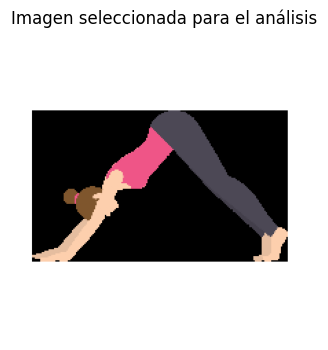

Estadísticas básicas de la imagen:

- Dimensiones: (224, 224, 3) (alto, ancho, canales de color)
- Valor mínimo: 0.000  → indica el tono más oscuro encontrado (cercano a negro).
- Valor máximo: 1.000  → indica el tono más claro encontrado (cercano a blanco).
- Promedio general (brillo): 0.644  → muestra cuán luminosa es la imagen en promedio.
- Desviación estándar: 0.459  → mide el contraste: si es alto, hay más diferencia entre luces y sombras.


In [ ]:
# ANÁLISIS ESTADÍSTICO DE LA IMAGEN SELECCIONADA

# En este bloque analizamos las características numéricas básicas de la imagen.
# Cada imagen se compone de tres canales de color (rojo, verde, azul),
# y cada píxel tiene un valor entre 0 y 1 (porque ya normalizamos los datos dividiendo entre 255).

# Estos valores indican la intensidad del color:
# - 0 representa ausencia total de color (negro)
# - 1 representa máxima intensidad (blanco o color brillante)

from tensorflow.keras.utils import load_img, img_to_array


img_path = "/content/yoga_poses_dataset/DATASET/TEST/downdog/00000010.png"
img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0  # Normalizamos dividiendo entre 255 para dejar los valores entre 0 y 1

# Mostrar la imagen
plt.figure(figsize=(4, 4))
plt.imshow(img_array)
plt.axis('off')
plt.title("Imagen seleccionada para el análisis")
plt.show()


# Calcular valores estadísticos
valor_minimo = np.min(img_array)     # El píxel más oscuro de toda la imagen
valor_maximo = np.max(img_array)     # El píxel más claro o brillante
promedio = np.mean(img_array)        # Promedio general del brillo
desviacion = np.std(img_array)       # Qué tanto varían los colores respecto al promedio

# Mostrar resultados con explicación
print("Estadísticas básicas de la imagen:\n")
print(f"- Dimensiones: {img_array.shape} (alto, ancho, canales de color)")
print(f"- Valor mínimo: {valor_minimo:.3f}  → indica el tono más oscuro encontrado (cercano a negro).")
print(f"- Valor máximo: {valor_maximo:.3f}  → indica el tono más claro encontrado (cercano a blanco).")
print(f"- Promedio general (brillo): {promedio:.3f}  → muestra cuán luminosa es la imagen en promedio.")
print(f"- Desviación estándar: {desviacion:.3f}  → mide el contraste: si es alto, hay más diferencia entre luces y sombras.")

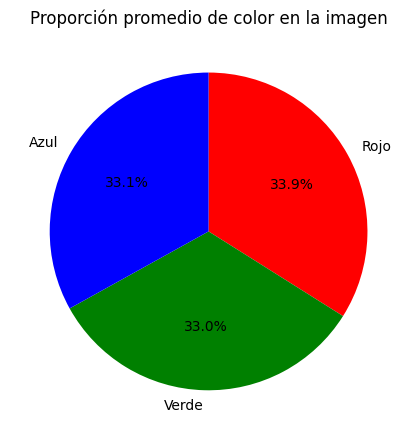

In [ ]:
# Gráfico de Torta — Proporción promedio de color

# Calculamos el promedio de intensidad de cada canal (rojo, verde y azul)
# Esto nos indica qué tanto contribuye cada color en la imagen.
mean_colors = np.mean(img_array, axis=(0, 1))

# Mostramos la proporción de colores en un gráfico circular
plt.figure(figsize=(4.5, 4.5))
plt.pie(
    mean_colors,
    labels=['Rojo', 'Verde', 'Azul'],
    colors=['red', 'green', 'blue'],
    autopct='%1.1f%%',
    startangle=90,          # comienza en la parte superior
    counterclock=False      # orden de sentido horario
)
plt.title("Proporción promedio de color en la imagen")
plt.tight_layout()
plt.show()

**Interpretación:**


------


* La imagen tiene un tamaño de 224 por 224 píxeles y tres canales de color (rojo, verde y azul), lo que confirma que se trata de una fotografía a color.

* Se observan zonas muy oscuras y muy claras, lo que muestra un buen rango de iluminación.

* El brillo promedio (0.64) indica que la imagen es bastante clara, con buena luz general.

* La desviación estándar (0.46) nos dice que hay contraste moderado, es decir, se diferencian bien las partes iluminadas de las sombras.

* En conjunto, es una imagen bien iluminada y con buena definición, lo que facilita que el modelo pueda reconocer sin dificultad la postura de yoga.

* La imagen  00000010.png tiene los tres colores rojo, verde y azul casi en la misma cantidad.
Esto significa que los tonos están bien balanceados y no resalta ningún color en particular.

* La iluminación parece uniforme, sin zonas que se vean demasiado frías (azuladas) ni cálidas (rojizas).
En general, es una imagen bien balanceada, con colores suaves y agradables que ayudan a distinguir bien la postura.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Resultado de la predicción:
- Postura detectada: downdog
- Nivel de confianza: 0.99


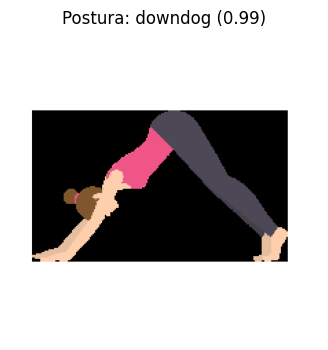

In [ ]:
# Predicción de la postura utilizando el modelo entrenado

# 1. Cargar el modelo entrenado
model = load_model("/content/modelo_yoga_kaggle.h5")

# 2️. Definir las clases (en el mismo orden del entrenamiento)
class_names = ['downdog', 'goddess', 'plank', 'tree', 'warrior2']

# 3️. Preparar la imagen (usamos la misma que analizamos antes)
img_ready = np.expand_dims(img_array, axis=0)  # Agrega una dimensión para el modelo

# 4️. Hacer la predicción
pred = model.predict(img_ready)
predicted_class = class_names[np.argmax(pred)]   # Clase con mayor probabilidad
confidence = np.max(pred)                        # Nivel de confianza

# 5️. Mostrar resultado
print("Resultado de la predicción:")
print(f"- Postura detectada: {predicted_class}")
print(f"- Nivel de confianza: {confidence:.2f}")

# 6️. Mostrar la imagen con el nombre de la clase predicha
plt.figure(figsize=(4,4))
plt.imshow(img_array)
plt.axis('off')
plt.title(f"Postura: {predicted_class} ({confidence:.2f})")
plt.show()

**Evaluación del modelo**


**Analiza el modelo entrenado utilizando las siguientes métricas**


-----



En este paso revisamos qué tan bien funciona el modelo con las imágenes del conjunto de validación.
Primero, comparamos las posturas reales con las que el modelo predice, y registramos también las probabilidades que asigna a cada clase.

Luego, analizamos tres indicadores principales:

1. Precisión, que muestra cuántas predicciones fueron correctas.

2. Recall, que indica cuántas posturas reales logró identificar.

3. F1-score, que resume el equilibrio entre ambas medidas.

Finalmente, graficamos las curvas ROC, que permiten ver qué tan bien distingue el modelo una postura de otra.
Cuanto más cerca esté cada curva del borde superior izquierdo, mejor está aprendiendo el modelo.

Modelo cargado correctamente y listo para evaluar.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

--- Evaluación del modelo sobre el conjunto de validación ---

              precision    recall  f1-score   support

     downdog      0.800     0.783     0.791        46
     goddess      0.870     0.606     0.714        33
       plank      0.825     0.754     0.788        69
        tree      0.909     0.833     0.870        24
    warrior2      0.635     0.909     0.748        44

    accuracy                          0.778       216
   macro avg      0.808     0.777     0.782       216
weighted avg      0.797     0.778     0.778       216



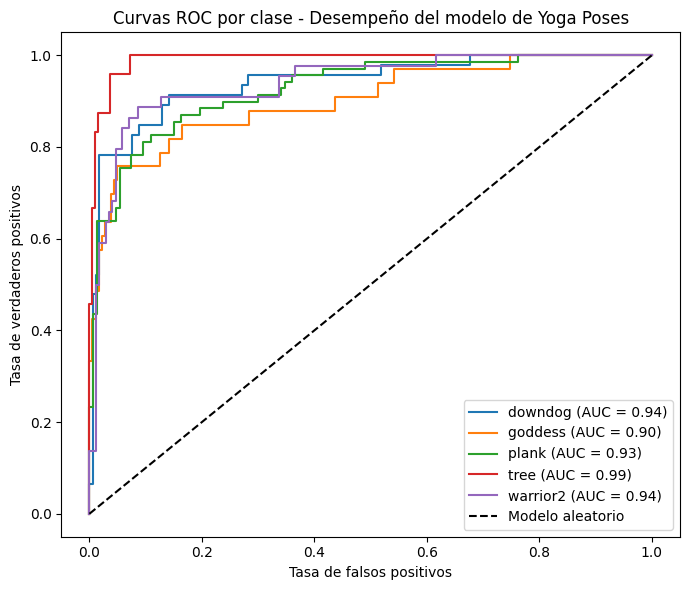

In [ ]:
# 1️. REVISAMOS CÓMO PREDICE EL MODELO

# Evaluación del modelo de Yoga Poses

# En este bloque analizamos cómo se comporta el modelo que entrenamos previamente.
# Usaremos el conjunto de validación para comprobar si el modelo realmente aprendió
# a reconocer las posturas correctamente y qué tan bien distingue una de otra.


# 1️. CARGAMOS EL MODELO GUARDADO

# Aquí traemos el modelo ya entrenado que se guardó en formato .h5.
# Esto nos permite evaluarlo sin tener que volver a entrenarlo desde cero.
model = load_model("/content/modelo_yoga_kaggle.h5")
print("Modelo cargado correctamente y listo para evaluar.")


# 2️. REVISAMOS CÓMO PREDICE EL MODELO

# En este paso comprobamos cómo el modelo clasifica las imágenes del conjunto de validación.
# Guardamos tres cosas:
# - Las posturas reales (etiquetas verdaderas)
# - Las posturas que el modelo predijo (sus respuestas)
# - Las probabilidades que el modelo asignó a cada clase

y_true = []  # Etiquetas reales
y_pred = []  # Etiquetas predichas por el modelo
y_prob = []  # Probabilidades asignadas a cada clase

for images, labels in val_ds:
    preds = model.predict(images)                   # Predicciones del modelo
    y_true.extend(labels.numpy())                   # Guardamos la postura real
    y_pred.extend(np.argmax(preds, axis=1))         # Guardamos la postura que el modelo eligió
    y_prob.extend(preds)                            # Guardamos las probabilidades por clase

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


# 3️. EVALUAMOS EL DESEMPEÑO DEL MODELO

# Aquí analizamos las métricas más importantes del modelo:
# - Precisión (precision): mide qué tan correctas fueron las predicciones.
# - Recall (sensibilidad): mide cuántas posturas reales logró identificar correctamente.
# - F1-score: combina precisión y recall para dar una medida general del desempeño.
print("\n--- Evaluación del modelo sobre el conjunto de validación ---\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))


# 4️. GRAFICAMOS LAS CURVAS ROC (RENDIMIENTO POR CLASE)

# Las curvas ROC nos muestran qué tan bien el modelo diferencia una clase de otra.
# Cada curva representa una postura de yoga.
# Cuanto más se acerque una curva al borde superior izquierdo, mejor está aprendiendo el modelo.

# Primero convertimos las etiquetas reales a formato binario (one-hot encoding),
# porque las curvas ROC necesitan ese formato.
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

# Creamos la figura
plt.figure(figsize=(7, 6))

# Dibujamos la curva ROC para cada clase
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

# La línea gris representa un modelo que adivina al azar.
# Cuanto más alejadas estén las curvas de esta línea, mejor es el rendimiento del modelo.
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatorio')

plt.title("Curvas ROC por clase - Desempeño del modelo de Yoga Poses")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación:**

-----


* El modelo tiene un buen desempeño general, con una precisión total cercana al 78%, lo que significa que acierta en la mayoría de las imágenes.

* Entre las posturas, se destacan tree y downdog, que fueron las mejor reconocidas, con valores altos tanto en precisión como en recall. Esto indica que el modelo identifica correctamente estas poses y rara vez las confunde.

* Las posturas plank y warrior2 también se reconocen bien, aunque en algunos casos se parecen entre sí y eso puede generar confusiones.
En cambio, goddess fue la más difícil de detectar: el modelo acierta cuando la predice, pero a veces no la reconoce cuando está presente.

* Las curvas ROC muestran que el modelo distingue bien las diferentes posturas, con valores altos en todas las clases. En general, el sistema aprende a reconocer las poses de yoga con bastante precisión, aunque todavía puede mejorar en algunas más parecidas entre sí.